In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install earthengine-api geemap rasterio scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.5 MB/s eta 0:00:00


In [3]:
import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt
import os

In [5]:
ee.Authenticate()
ee.Initialize(project='gen-lang-client-0412024487')

In [6]:
california_roi = ee.Geometry.Rectangle([

    -124.5,
    36.5,

    -119.0,
    41.5
])

In [7]:
Map = geemap.Map()

Map.centerObject(california_roi, 6)

Map.addLayer(california_roi, {}, "California ROI")

Map

Map(center=[39.00272451346356, -121.75000000000001], controls=(WidgetControl(options=['position', 'transparent…

In [8]:
ndvi_collection = ee.ImageCollection("MODIS/061/MOD13Q1")

In [9]:
ndvi = (
    ndvi_collection
    .filterBounds(california_roi)
    .filterDate("2025-06-01", "2025-06-30")
    .select("NDVI")
    .mean()
)

In [10]:
print(ndvi.getInfo())

{'type': 'Image', 'bands': [{'id': 'NDVI', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': -32768, 'max': 32767}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}]}


In [11]:
ndvi = ndvi.multiply(0.0001)

In [12]:
Map = geemap.Map()

Map.centerObject(california_roi, 6)

ndvi_vis = {
    "min": 0,
    "max": 1,
    "palette": ["white", "green"]
}

Map.addLayer(ndvi.clip(california_roi), ndvi_vis, "California NDVI")

Map

Map(center=[39.00272451346356, -121.75000000000001], controls=(WidgetControl(options=['position', 'transparent…

In [13]:
export_path = "/content/california_ndvi.tif"

geemap.ee_export_image(
    ndvi.clip(california_roi),
    filename=export_path,
    scale=500,
    region=california_roi,
    file_per_band=False
)

print("California NDVI exported successfully.")

Generating URL ...
Please wait ...
Data downloaded to /content/california_ndvi.tif
California NDVI exported successfully.


In [14]:
import rasterio

src = rasterio.open(export_path)

ndvi_array = src.read(1)

print(ndvi_array.shape)

(1121, 1225)


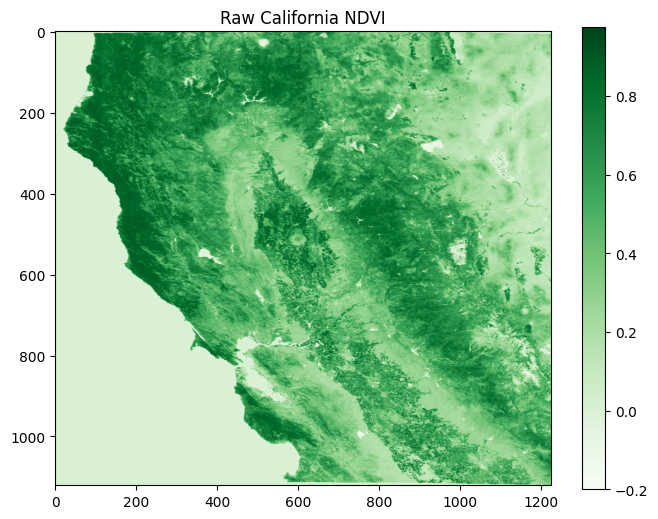

In [15]:
plt.figure(figsize=(8,6))

plt.imshow(ndvi_array, cmap="Greens")

plt.title("Raw California NDVI")

plt.colorbar()

plt.show()

In [16]:
ndvi_array = np.nan_to_num(ndvi_array)

ndvi_array[ndvi_array < 0] = 0

In [17]:
def normalize(x):
    return (x - x.min()) / (x.max() - x.min())

In [18]:
fuel = normalize(ndvi_array)

In [19]:
print(fuel.min())
print(fuel.max())

0.0
1.0


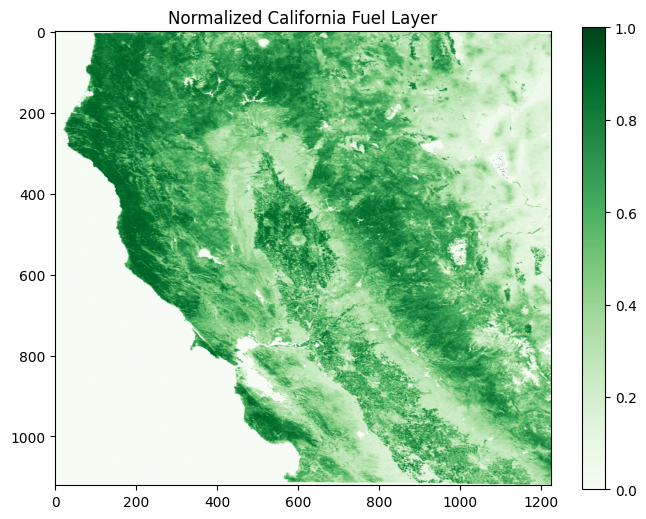

In [20]:
plt.figure(figsize=(8,6))

plt.imshow(fuel, cmap="Greens")

plt.title("Normalized California Fuel Layer")

plt.colorbar()

plt.show()

In [21]:
from skimage.transform import resize

In [22]:
GRID_32 = (32,32)

GRID_64 = (64,64)

In [23]:
fuel_32 = resize(fuel, GRID_32)

fuel_64 = resize(fuel, GRID_64)

In [24]:
print(fuel_32.shape)

print(fuel_64.shape)

(32, 32)
(64, 64)


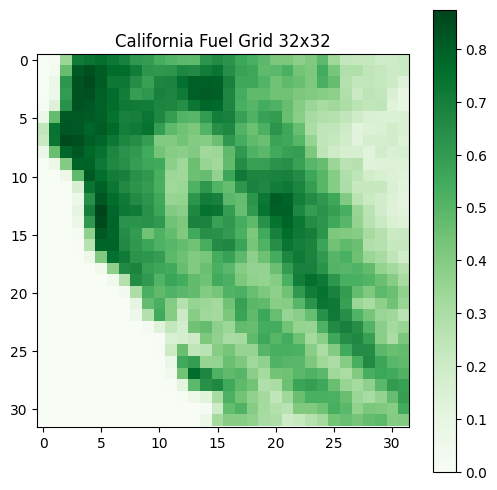

In [25]:
plt.figure(figsize=(6,6))

plt.imshow(fuel_32, cmap="Greens")

plt.title("California Fuel Grid 32x32")

plt.colorbar()

plt.show()

In [26]:
BASE = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/california/grids"

os.makedirs(f"{BASE}/32x32", exist_ok=True)

os.makedirs(f"{BASE}/64x64", exist_ok=True)

In [27]:
np.save(f"{BASE}/32x32/fuel.npy", fuel_32)

print("California fuel 32x32 saved.")

California fuel 32x32 saved.


In [28]:
np.save(f"{BASE}/64x64/fuel.npy", fuel_64)

print("California fuel 64x64 saved.")

California fuel 64x64 saved.


In [29]:
grid_path = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/california/grids/32x32"

print(os.listdir(grid_path))

['wind_x.npy', 'wind_y.npy', 'temperature.npy', 'humidity.npy', 'fire.npy', 'terrain.npy', 'fuel.npy']


In [30]:
fuel_loaded = np.load(f"{grid_path}/fuel.npy")

print(fuel_loaded.shape)

print(fuel_loaded.min())

print(fuel_loaded.max())

(32, 32)
0.0
0.8747476204467842
